In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Understanding

In [2]:
# Loading the loan status data as well as the data dictionary

data = pd.read_csv("loan.csv")
data_dict = pd.read_excel("Data_Dictionary.xlsx")

/var/folders/rq/qxt5246d1fq2wcgw93y6_hjm0000gn/T/ipykernel_43052/836203894.py:3: DtypeWarning: Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("loan.csv")


In [3]:
# Going through the data dictionary to understand the meaning of each of the columns in loan.csv dataset
data_dict.head()

,LoanStatNew,Description
0,acc_now_delinq,The number of accounts on which the borrower i...
1,acc_open_past_24mths,Number of trades opened in past 24 months.
2,addr_state,The state provided by the borrower in the loan...
3,all_util,Balance to credit limit on all trades
4,annual_inc,The self-reported annual income provided by th...


In [4]:
# Viewing the top 5 rows of the loan data
data.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,1077501,1296599,5000,5000,4975.0,36 months,10.65%,162.87,B,B2,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
1,1077430,1314167,2500,2500,2500.0,60 months,15.27%,59.83,C,C4,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2,1077175,1313524,2400,2400,2400.0,36 months,15.96%,84.33,C,C5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
3,1076863,1277178,10000,10000,10000.0,36 months,13.49%,339.31,C,C1,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
4,1075358,1311748,3000,3000,3000.0,60 months,12.69%,67.79,B,B5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN


In [5]:
# Shape of the loan data
data.shape

(39717, 111)

In [6]:
data.iloc[:,:100].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 100 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              39717 non-null  int64  
 1   member_id                       39717 non-null  int64  
 2   loan_amnt                       39717 non-null  int64  
 3   funded_amnt                     39717 non-null  int64  
 4   funded_amnt_inv                 39717 non-null  float64
 5   term                            39717 non-null  object 
 6   int_rate                        39717 non-null  object 
 7   installment                     39717 non-null  float64
 8   grade                           39717 non-null  object 
 9   sub_grade                       39717 non-null  object 
 10  emp_title                       37258 non-null  object 
 11  emp_length                      38642 non-null  object 
 12  home_ownership                 

In [7]:
data.describe()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
count,3.971700e+04,3.971700e+04,39717.000000,39717.000000,39717.000000,39717.000000,3.971700e+04,39717.000000,39717.000000,39717.000000,...,0.0,0.0,0.0,0.0,39020.000000,39678.0,0.0,0.0,0.0,0.0
mean,6.831319e+05,8.504636e+05,11219.443815,10947.713196,10397.448868,324.561922,6.896893e+04,13.315130,0.146512,0.869200,...,NaN,NaN,NaN,NaN,0.043260,0.0,NaN,NaN,NaN,NaN
std,2.106941e+05,2.656783e+05,7456.670694,7187.238670,7128.450439,208.874874,6.379377e+04,6.678594,0.491812,1.070219,...,NaN,NaN,NaN,NaN,0.204324,0.0,NaN,NaN,NaN,NaN
min,5.473400e+04,7.069900e+04,500.000000,500.000000,0.000000,15.690000,4.000000e+03,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,0.000000,0.0,NaN,NaN,NaN,NaN
25%,5.162210e+05,6.667800e+05,5500.000000,5400.000000,5000.000000,167.020000,4.040400e+04,8.170000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,0.000000,0.0,NaN,NaN,NaN,NaN
50%,6.656650e+05,8.508120e+05,10000.000000,9600.000000,8975.000000,280.220000,5.900000e+04,13.400000,0.000000,1.000000,...,NaN,NaN,NaN,NaN,0.000000,0.0,NaN,NaN,NaN,NaN
75%,8.377550e+05,1.047339e+06,15000.000000,15000.000000,14400.000000,430.780000,8.230000e+04,18.600000,0.000000,1.000000,...,NaN,NaN,NaN,NaN,0.000000,0.0,NaN,NaN,NaN,NaN
max,1.077501e+06,1.314167e+06,35000.000000,35000.000000,35000.000000,1305.190000,6.000000e+06,29.990000,11.000000,8.000000,...,NaN,NaN,NaN,NaN,2.000000,0.0,NaN,NaN,NaN,NaN


### Observations 

1. The loan dataset contains information for 39717 loans aganist 110 features
2. A singnificant number of columns have missing values. Some of the columns like acc_now_delinq, tot_coll_amt, tot_cur_bal, open_acc_6m, open_il_6m, open_il_12m etc are entirely missing. It indicates that these columns were not filled by the applicant/bank or were not applicable to  loans in the data
3. The dataset contains numerical and categorical data. Some numerical data like 'int_rate' might be stored as string objects due to presence of '%'. These might require cleaning to convert them to numerical values for qunatative analysis.

# 2. Data Cleaning and Manipulation

In [8]:
# Check for missing values

missing_values = data.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

missing_values

bc_open_to_buy                39717
acc_open_past_24mths          39717
bc_util                       39717
mo_sin_old_il_acct            39717
mo_sin_old_rev_tl_op          39717
                              ...  
collections_12_mths_ex_med       56
revol_util                       50
tax_liens                        39
title                            11
last_credit_pull_d                2
Length: 68, dtype: int64

In [9]:
#Identify columns where the missing values is above a certain threshold

threshold_to_drop = len(data) * 0.5 #remove a column if it has 50% values as null
columns_to_drop = missing_values[missing_values > threshold_to_drop].index.tolist()

In [10]:
# Drop the identified columns from the dataset

data_cleaned = data.drop(columns = columns_to_drop)

In [11]:
data_cleaned.shape

(39717, 54)

In [12]:
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 54 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          39717 non-null  int64  
 1   member_id                   39717 non-null  int64  
 2   loan_amnt                   39717 non-null  int64  
 3   funded_amnt                 39717 non-null  int64  
 4   funded_amnt_inv             39717 non-null  float64
 5   term                        39717 non-null  object 
 6   int_rate                    39717 non-null  object 
 7   installment                 39717 non-null  float64
 8   grade                       39717 non-null  object 
 9   sub_grade                   39717 non-null  object 
 10  emp_title                   37258 non-null  object 
 11  emp_length                  38642 non-null  object 
 12  home_ownership              39717 non-null  object 
 13  annual_inc                  397

In [22]:
# calculating the percentage of missing data in each column

percent_missing_values = (data_cleaned.isnull().sum()/len(data_cleaned))*100
percent_missing_values[percent_missing_values > 0]

emp_title                      6.191303
emp_length                     2.706650
desc                          32.585543
title                          0.027696
last_pymnt_d                   0.178765
last_credit_pull_d             0.005036
collections_12_mths_ex_med     0.140998
chargeoff_within_12_mths       0.140998
pub_rec_bankruptcies           1.754916
tax_liens                      0.098195
dtype: float64

In [14]:
# Converting 'int_rate', 'revol_util' from object to float datatype
data_cleaned['int_rate'] = data_cleaned['int_rate'].str.strip('%').astype('float')

In [15]:
# Converting 'revol_util' from object to float datatype
data_cleaned['revol_util'] = data_cleaned['revol_util'].astype(str).str.rstrip('%').astype(float) / 100 # first convert the datatype to string and then strip the '%'
data_cleaned['revol_util'] = data_cleaned['revol_util'].replace('', np.nan).astype(float) #replace empty string back to NaN

In [16]:
# converting the 'issue_d', 'earliest_cr_line', 'last_pymnt_d ', 'last_credit_pull_d' to datetime format

data_cleaned['issue_d'] = pd.to_datetime(data_cleaned['issue_d'], format='%b-%y')
data_cleaned['earliest_cr_line'] = pd.to_datetime(data_cleaned['earliest_cr_line'], format='%b-%y')
data_cleaned['last_pymnt_d'] = pd.to_datetime(data_cleaned['last_pymnt_d'], format='%b-%y')
data_cleaned['last_credit_pull_d'] = pd.to_datetime(data_cleaned['last_credit_pull_d'], format='%b-%y')

count    39717.000000
mean         0.488327
std          0.283148
min          0.000000
25%          0.255000
50%          0.493000
75%          0.723000
max          0.999000
Name: revol_util, dtype: float64

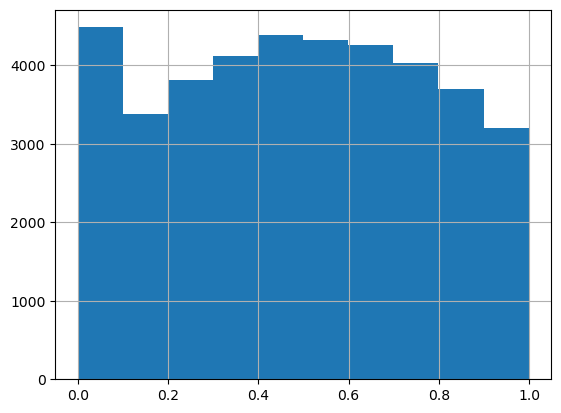

In [21]:
# understanding the distribution of 'revol_util'
data_cleaned['revol_util'].hist()

data_cleaned['revol_util'].describe()

In [20]:
# Imputing missing values for 'revol_util'

data_cleaned['revol_util'].fillna(data_cleaned['revol_util'].median(), inplace=True) #using the median as the inpute value since median is less sensitive to outliers 

### Observations

1. After dropping the columns with more than 75% of missing values, we are left with 54 columns
2. We still have 39717 records
3. 'int_rate' which is could be one of the most important driver of loan_status (based on business understanding) has been converted to float64 for quantitive analysis.
4. 'issue_d', 'earliest_cr_line', 'last_pymnt_d ', 'last_credit_pull_d' have been converted to the datetime format
5. Imputed the values of columns like 'revol_util'

# 3. Data analysis

## 3.1 Univariate Analysis

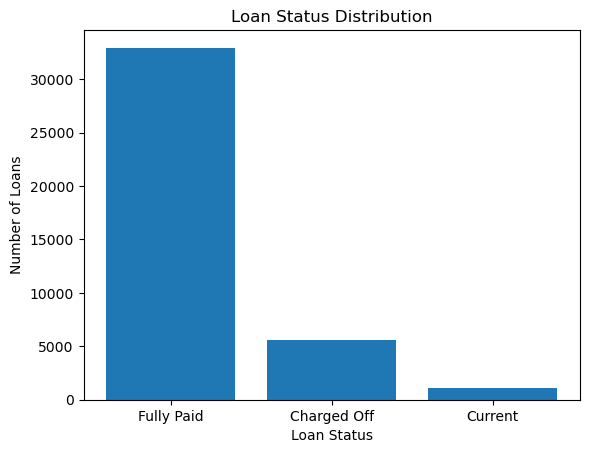

In [66]:
# Loan Status Distribution
loan_status_counts = data_cleaned['loan_status'].value_counts()
plt.bar(loan_status_counts.index, loan_status_counts.values)
plt.title('Loan Status Distribution')
plt.ylabel('Number of Loans')
plt.xlabel('Loan Status')
plt.show()

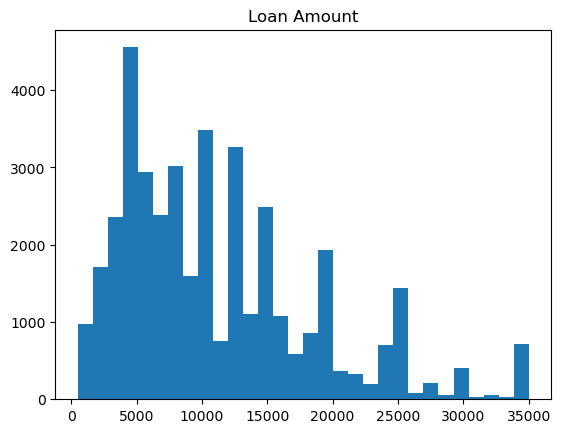

In [46]:
# Loan Amount Distribution
plt.hist(data_cleaned['loan_amnt'], bins=30)
plt.title('Loan Amount')
plt.show()

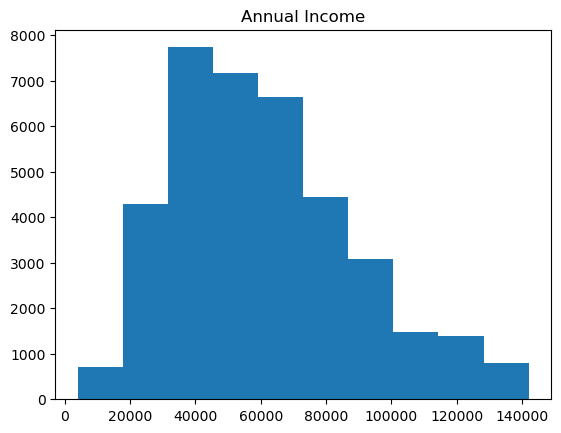

In [45]:
# Annual Income Distribution (Taking only 95th percentile for better visualization)
income_cap = data_cleaned['annual_inc'].quantile(0.95)
plt.hist(data_cleaned[data_cleaned['annual_inc'] < income_cap]['annual_inc'])
plt.title('Annual Income')
plt.show()

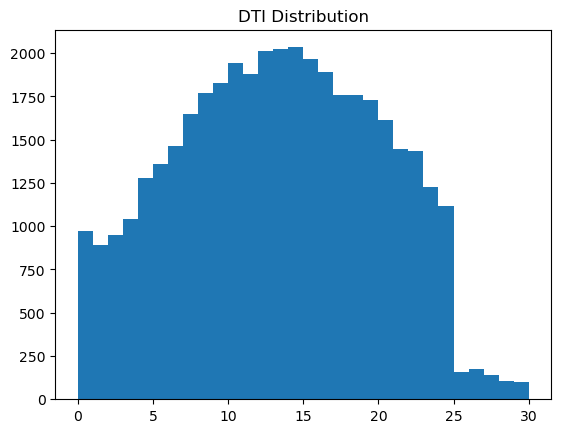

In [48]:
# DTI (Debt-to-Income Ratio) Distribution
plt.hist(data_cleaned['dti'], bins=30)
plt.title('DTI Distribution')
plt.show()

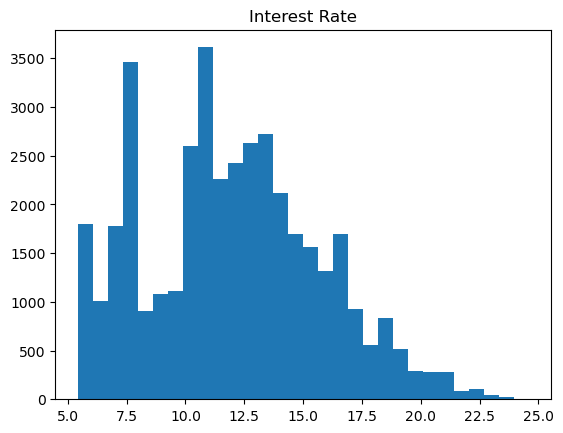

In [50]:
# Interest Rate Distribution
plt.hist(data_cleaned['int_rate'], bins=30)
plt.title('Interest Rate')
plt.show()

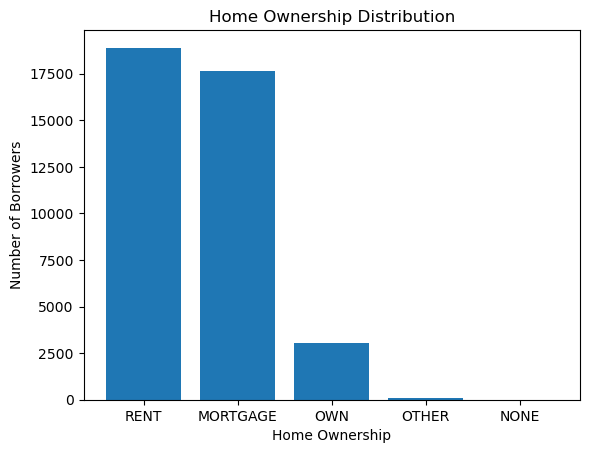

In [70]:
# Home Ownership Distribution
home_ownership_counts = data_cleaned['home_ownership'].value_counts()
plt.bar(home_ownership_counts.index, home_ownership_counts.values)
plt.title('Home Ownership Distribution')
plt.ylabel('Number of Borrowers')
plt.xlabel('Home Ownership')
plt.show()

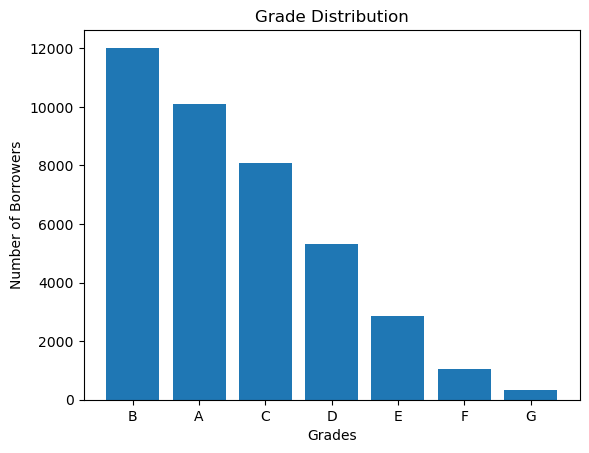

In [71]:
# Grade Distribution
grade_counts = data_cleaned['grade'].value_counts()
plt.bar(grade_counts.index, grade_counts.values)
plt.title('Grade Distribution')
plt.ylabel('Number of Borrowers')
plt.xlabel('Grades')
plt.show()

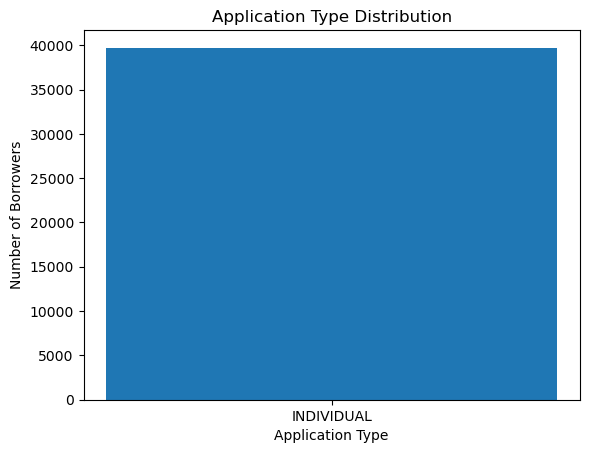

In [74]:
# application type Distribution
application_type_counts = data_cleaned['application_type'].value_counts()
plt.bar(application_type_counts.index, application_type_counts.values)
plt.title('Application Type Distribution')
plt.ylabel('Number of Borrowers')
plt.xlabel('Application Type')
plt.show()

### Observations

1. Loan Status Distribution: The distribution of Loan status show that the majority of loans is in the "Fully Paid" category, with a significant number in the "Charged Off" category, indicating default. This is critical for identifying patterns related to defaults.
2. Loan Amount Distribution: The distribution of loan amounts shows a right-skewed pattern, indicating that smaller loan amounts are more common than larger ones. 
3. Annual Income Distribution: The distribution of annual income shows that most borrowers have reported incomes in the lower to middle range. 
4. DTI (Debt-to-Income Ratio) Distribution: The DTI ratio has a relatively uniform distribution across a wide range of values, with a slight right skew. 
5. Interest Rate Distribution: The interest rate distribution does not readlily indicate any conventional pattern, reflecting different risk categories assigned to loans. 
6. Home Ownership DIstribition: The distribution of the home ownership show that most of borrowers rent their home or have a mortgage against the home. Only a small number have indicate own home ownership
7. Grade Distribution: The distribution of grades show that most borrowers are assigned in the grade B, followed by A, C, D and so on
8. Application type: 100% of applications are 'individual' indicating that this feature does not have any impact on the loan status

## 3.2. Segmented Univariate analysis

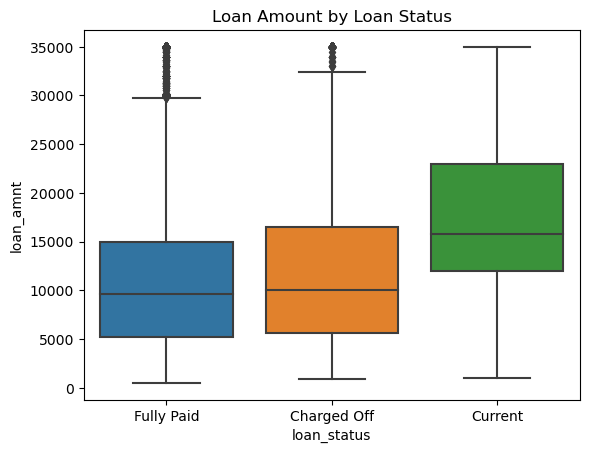

In [99]:
# Segmented Univariate analysis: Compare key variables by loan status

# Loan Amount vs. Loan Status
sns.boxplot(x='loan_status', y='loan_amnt', data=data_cleaned)
plt.title('Loan Amount by Loan Status')
plt.show()

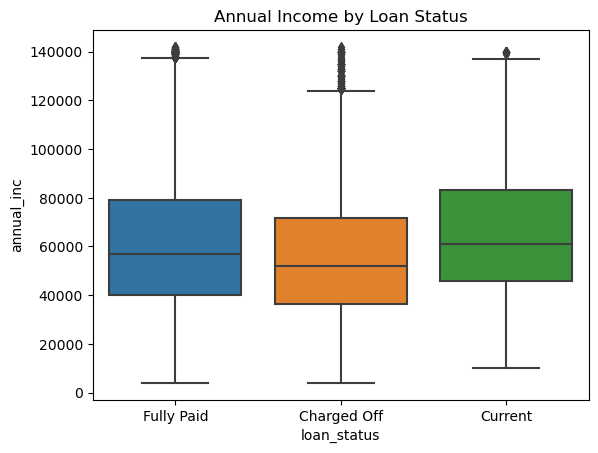

In [101]:
# Annual Income vs. Loan Status (capped at 95th percentile for better visualization)
sns.boxplot(x='loan_status', y='annual_inc', data=data_cleaned[data_cleaned['annual_inc'] < income_cap])
plt.title('Annual Income by Loan Status')
plt.show()

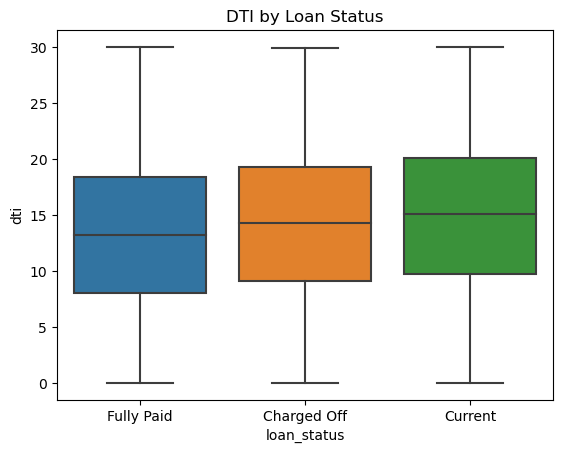

In [102]:
# DTI vs. Loan Status
sns.boxplot(x='loan_status', y='dti', data=data_cleaned)
plt.title('DTI by Loan Status')
plt.show()

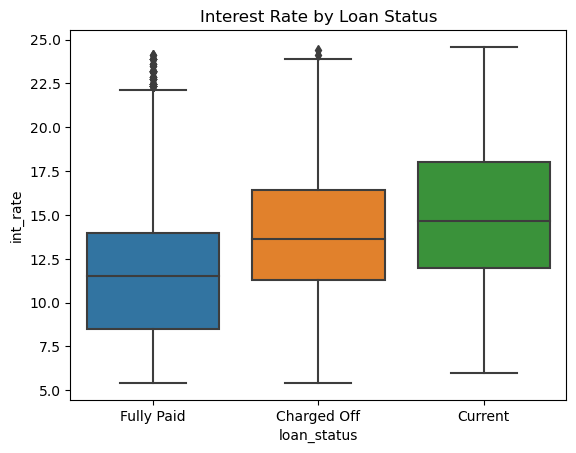

In [103]:
# Interest Rate vs. Loan Status
sns.boxplot(x='loan_status', y='int_rate', data=data_cleaned)
plt.title('Interest Rate by Loan Status')
plt.show()

### Observations

The segemented univariate of key variables by loan status reveals the following insights:

1. Loan Amount by Loan Status: The median loan amount for charged-off loans is slightly higher than for fully paid loans, suggesting that higher loan amounts may have a slightly increased risk of default. However, the difference is not substantial, indicating other factors also play a significant role in the likelihood of default.
2. Annual Income by Loan Status: The median annual income appears to be lower for charged-off loans compared to fully paid loans, though the difference is not very pronounced. This suggests that borrowers with lower incomes might be at a higher risk of default, but income alone is not a definitive predictor.
3. DTI (Debt-to-Income Ratio) by Loan Status: The median DTI ratio is higher for charged-off loans than for fully paid loans. This indicates that a higher debt-to-income ratio is associated with an increased risk of default, which aligns with the expectation that borrowers with higher financial obligations relative to their income are more likely to face difficulties in repaying their loans.
4. Interest Rate by Loan Status: There is a noticeable difference in the interest rates between fully paid and charged-off loans, with charged-off loans having higher median interest rates. This suggests that loans with higher interest rates, indicative of higher risk as assessed by the lender, are more likely to default.

## 3.3 Bivariate analysis

/var/folders/rq/qxt5246d1fq2wcgw93y6_hjm0000gn/T/ipykernel_43052/922896100.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filtered['loan_status_indicator'] = data_filtered['loan_status_indicator'].astype(int)


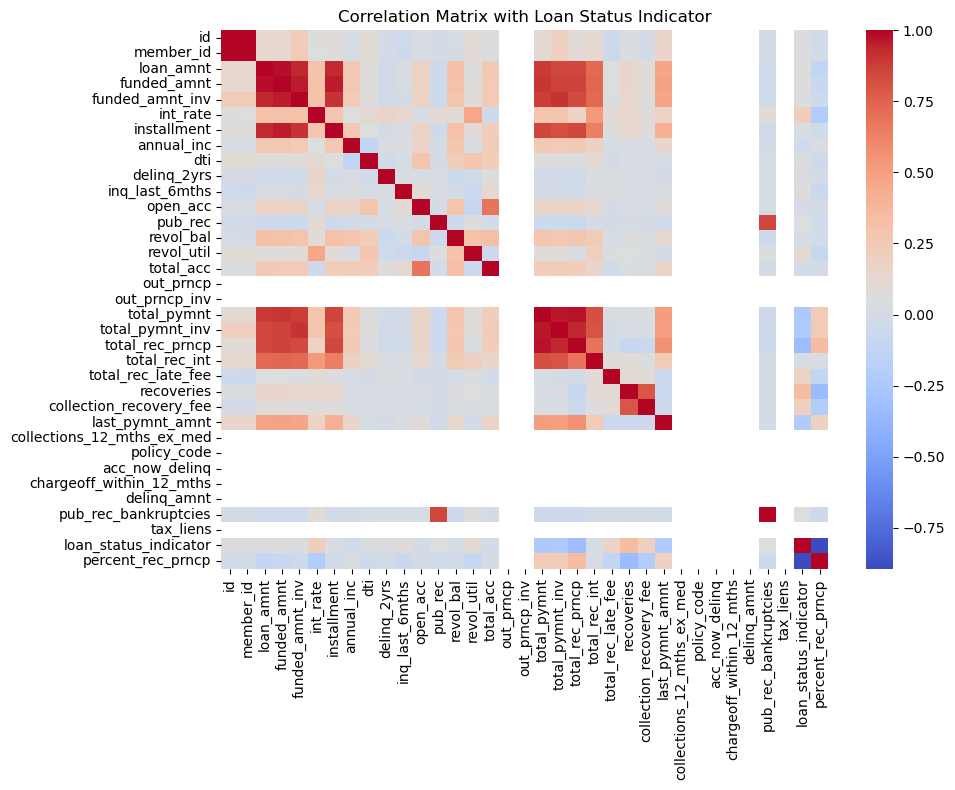

In [97]:
# Correlation analaysis of loan_status with other numerical features

# Convert 'loan_status' into a numerical indicator to find its correlation with other numerical features
data_cleaned['loan_status_indicator'] = data_cleaned['loan_status'].apply(lambda x: 1 if x == 'Charged Off' else (0 if x == 'Fully Paid' else None))

# Adding a business driven metric - percent_rec_prncp which indicates the % of loan amount that has been paid 
data_cleaned['percent_rec_prncp'] = (data_cleaned['total_rec_prncp']/data_cleaned['loan_amnt']) * 100

# Dropping rows where loan_status is 'Current' as they are not relevant for this analysis
data_filtered = data_cleaned.dropna(subset=['loan_status_indicator'])

# Convert 'loan_status_indicator' to integer type
data_filtered['loan_status_indicator'] = data_filtered['loan_status_indicator'].astype(int)

# Selecting numerical variables for correlation analysis
numerical_columns = data_filtered.select_dtypes(include=['float64', 'int64']).columns
numerical_data = data_filtered[numerical_columns]

# Recalculate the correlation matrix including 'loan_status_indicator'
correlation_matrix_with_indicator = numerical_data.corr()

# Plotting the updated correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_with_indicator, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix with Loan Status Indicator')
plt.tight_layout()
plt.show()

In [98]:
# Specifically looking at the correlation of variables with 'loan_status_indicator'
correlation_with_loan_status = correlation_matrix_with_indicator['loan_status_indicator'].sort_values(key=abs, ascending=False)
correlation_with_loan_status

loan_status_indicator         1.000000
percent_rec_prncp            -0.893785
recoveries                    0.339562
total_rec_prncp              -0.334944
total_pymnt                  -0.235898
total_pymnt_inv              -0.232906
last_pymnt_amnt              -0.222524
int_rate                      0.211390
collection_recovery_fee       0.204914
total_rec_late_fee            0.165115
revol_util                    0.099875
inq_last_6mths                0.071878
loan_amnt                     0.059463
funded_amnt                   0.056497
pub_rec                       0.051001
pub_rec_bankruptcies          0.047757
dti                           0.045078
id                            0.042390
annual_inc                   -0.040867
member_id                     0.039798
funded_amnt_inv               0.037781
installment                   0.027153
total_acc                    -0.022608
delinq_2yrs                   0.020096
total_rec_int                 0.013008
open_acc                 

### Observations:

1. Interest Rate (int_rate): Higher interest rates may correlate with a higher likelihood of default, as they indicate riskier loans.
2. Loan Amount (loan_amnt): Larger loan amounts could have a higher default risk. Most ptobably due to the increased financial burden on the borrower.
3. Annual Income (annual_inc): Borrowers with higher annual incomes might be less likely to default, reflecting a negative correlation with the default indicator.
4. Debt-to-Income Ratio (dti): A higher DTI ratio might show a positive correlation with default risk, indicating that borrowers with a higher debt load relative to their income are more likely to default.
5. installment (installment) : A positive correlation between the installament and loan_status is observed indicating that a higher monthly payment installaments may have a highler likelihood of default. This is most probably due to increased burden of payment on the borrowers. 
6. Pencent of Principal Paid (percent_rec_prncp): Borrowers who have  paid higher perncetage of loan amount are less likely to default. This can be explained by the fact that borrowers with higher payments have higher motivation to complete the payment and close the loan.

In [93]:
data_cleaned.pivot_table

0         5863.155187
1         1008.710000
2         3005.666844
3        12231.890000
4         3513.330000
             ...     
39712     2822.969293
39713     9913.491822
39714     5272.161128
39715     5174.198551
39716     9195.263334
Name: total_pymnt, Length: 39717, dtype: float64

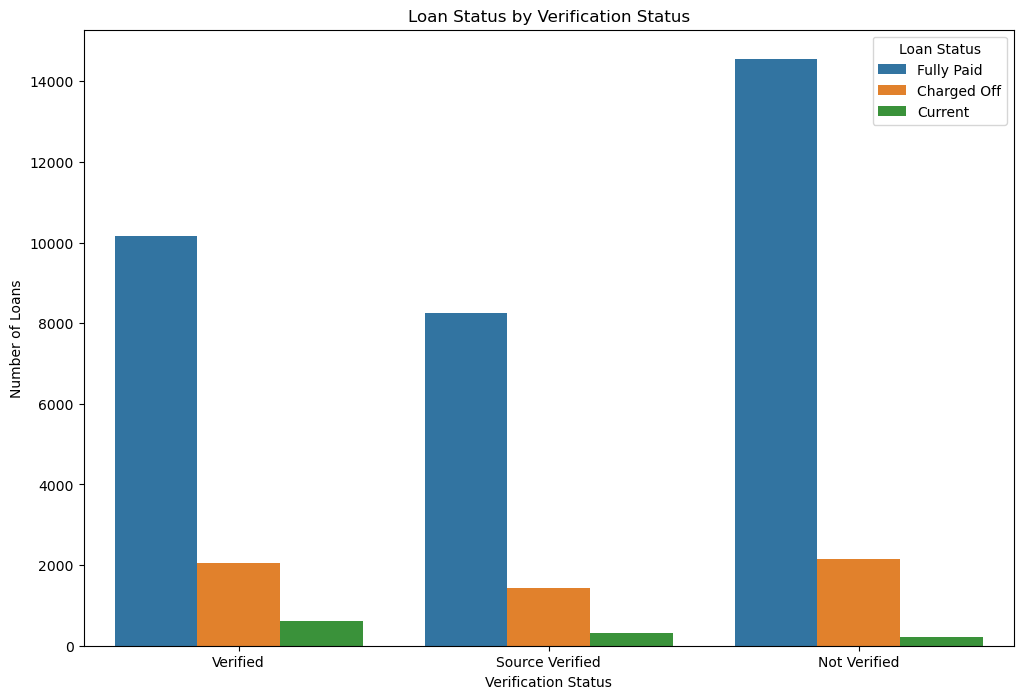

,verification_status,Charge-Off Rate
0,Not Verified,0.126588
1,Source Verified,0.143587
2,Verified,0.160122


In [107]:
# Bivariate Analysis: Relationship between Verification Status and Loan Status

plt.figure(figsize=(12, 8))
sns.countplot(x='verification_status', hue='loan_status', data=data_cleaned)
plt.title('Loan Status by Verification Status')
plt.xlabel('Verification Status')
plt.ylabel('Number of Loans')
plt.legend(title='Loan Status')
plt.show()

# Calculate the proportion of charged-off loans by verification status
charged_off_rates = data_cleaned.groupby('verification_status')['loan_status'].apply(lambda x: (x == 'Charged Off').mean()).reset_index()
charged_off_rates.rename(columns={'loan_status': 'Charge-Off Rate'}, inplace=True)

charged_off_rates


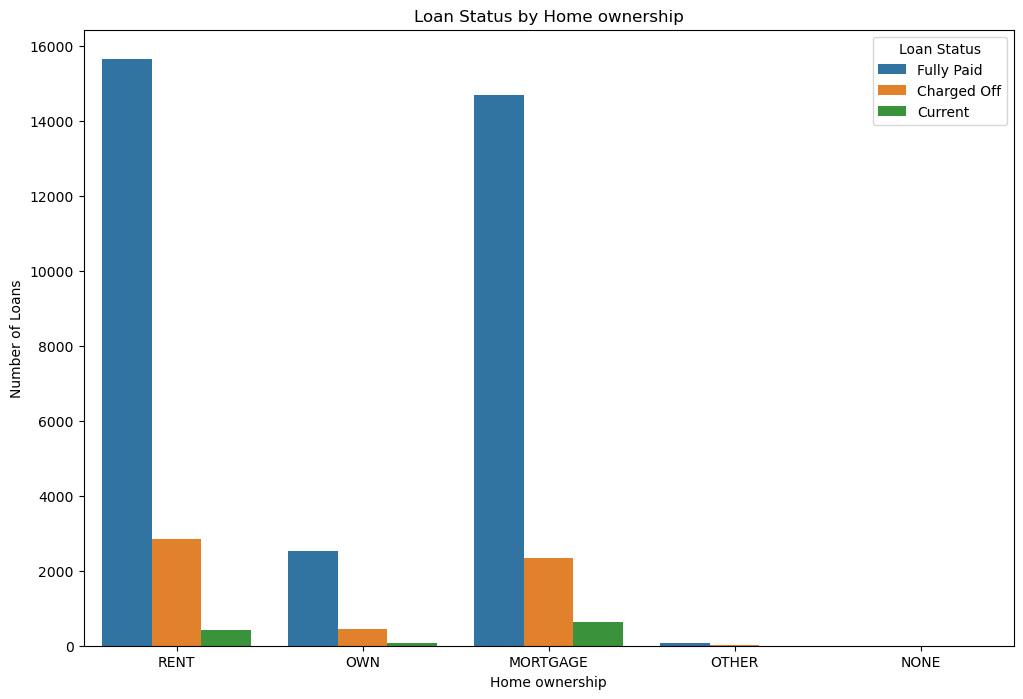

,home_ownership,Charge-Off Rate
0,MORTGAGE,0.131774
1,NONE,0.000000
2,OTHER,0.183673
3,OWN,0.144866
4,RENT,0.150220


In [108]:
# Bivariate Analysis: Relationship between Home Ownership and Loan Status

plt.figure(figsize=(12, 8))
sns.countplot(x='home_ownership', hue='loan_status', data=data_cleaned)
plt.title('Loan Status by Home ownership')
plt.xlabel('Home ownership')
plt.ylabel('Number of Loans')
plt.legend(title='Loan Status')
plt.show()

# Calculate the proportion of charged-off loans by verification status
charged_off_rates = data_cleaned.groupby('home_ownership')['loan_status'].apply(lambda x: (x == 'Charged Off').mean()).reset_index()
charged_off_rates.rename(columns={'loan_status': 'Charge-Off Rate'}, inplace=True)

charged_off_rates


# 4. Recommendations
Based on these findings, to mitigate the risk of loan defaults, the company could consider the following actions:

1. DTI Ratios: Applicants with high DTI ratios could be subjected to more stringent review processes.
2. Interest Rate Adjustments: Higher interest rates correlate with higher default rates. Adjusting lending criteria or pricing for these loans could help balance risk and return.
3. Annual Income (annual_inc): Lending club should do additonal judgements of those borrowers with relatively lower annual incone due to higher risk of default. 
4. Loan Amount Limits: Implementing stricter limits or higher scrutiny for larger loan amounts could also help manage default risk.


Ideally the company should target borrowers with higher income but for relatively lower income borrowers loan default risk can be mitigated for them by providing lower loan amounts,  have lower installments, lower interests etc